In [1]:
import numpy as np
import pandas as pd
import plotly.express as plotly
import plotly.io as pio

## **Creating Data Points**

In [2]:
np.random.seed(23)  # generating same sequence of random numbers everytime program runs

# creating sample data points for 3 features
mean_vector1 = np.array([0,0,0])     # 3 features and each has mean = 0
covariance_matrix1 = np.array([       # variance = 1, covariance = 0
    [1,0,0],
    [0,1,0],
    [0,0,1]
])
sample_points1 = np.random.multivariate_normal(
    mean_vector1,
    covariance_matrix1,
    20
)

mean_vector2 = np.array([1,1,1])     # 3 features and each has mean = 1
covariance_matrix2 = np.array([       # variance = 1, covariance = 0
    [1,0,0],
    [0,1,0],
    [0,0,1]
])
sample_points2 = np.random.multivariate_normal(
    mean_vector2,
    covariance_matrix2,
    20
)

df1 = pd.DataFrame(
    data = sample_points1,
    columns = ['Feature 1', 'Feature 2', 'Feature 3']
)
df1['Target'] = 0

df2 = pd.DataFrame(
    data = sample_points2,
    columns = ['Feature 1', 'Feature 2', 'Feature 3']
)
df2['Target'] = 1

df = pd.concat([df1, df2], axis = 0)     # axis = 0 to append row wise
df = df.sample(frac=1, random_state=23).reset_index(drop=True)

In [3]:
df.sample(5)

,Feature 1,Feature 2,Feature 3,Target
2,0.241106,-0.952510,-0.136267,0
34,2.011059,1.920996,2.933090,1
14,1.045371,0.538162,0.812119,0
11,1.250737,0.186384,1.703624,1
12,-1.389866,0.666726,1.343517,1


In [25]:
figure = plotly.scatter_3d(
    df,
    x=df['Feature 1'],
    y=df['Feature 2'],
    z=df['Feature 3'],
    color=df['Target'].astype('str')
)

figure.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

pio.renderers.default = "notebook_connected"
figure.show()

## **Mean Centering**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.iloc[:, 0:3] = scaler.fit_transform(df.iloc[:, 0:3])

## **Covariance Matrix**

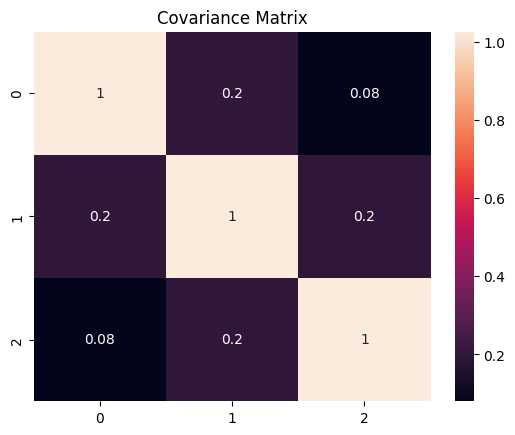

In [14]:
import seaborn as sb
import matplotlib.pyplot as plt
covariance_matrix = np.cov(df.iloc[:, 0:3].values, rowvar=False)
sb.heatmap(covariance_matrix, annot=True)

plt.title("Covariance Matrix")
plt.show()

## **Eigen vectors and values**

In [20]:
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

print("Eigen values : ", eigen_values)
print("Eigen vectors : \n", eigen_vectors)

Eigen values :  [1.3536065  0.94557084 0.77774573]
Eigen vectors : 
 [[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


In [33]:
import plotly.graph_objects as go

fig = go.Figure()

for i in range(3):
    v = eigen_vectors[:, i] * eigen_values[i]

    fig.add_trace(go.Scatter3d(
        x=[0, v[0]],
        y=[0, v[1]],
        z=[0, v[2]],
        mode='lines',
        line=dict(width=6),
        name=f"Eigenvector {i+1}"
    ))

fig.show()

### **Principal components**

In [37]:
pc = eigen_vectors[0:2]
pc1 = eigen_vectors[0]
pc2 = eigen_vectors[1]

In [35]:
pc1

array([-0.53875915, -0.69363291,  0.47813384])

In [41]:
pc2

array([-0.65608325, -0.01057596, -0.75461442])

In [42]:
pc.shape

(2, 3)

## **3D to 2D**

In [44]:
reduced_df = np.dot(df.iloc[:, 0:3], pc.T)

new_df = pd.DataFrame(reduced_df, columns=['PC1', 'PC2'])
new_df['Target'] = df['Target'].values

In [45]:
new_df.sample(5)

,PC1,PC2,Target
20,-1.320157,-0.257002,1
24,-0.621586,0.023110,0
32,-0.069178,-0.130994,1
17,-0.478444,0.774372,0
36,-0.470834,-1.373121,1


## **Result**

In [46]:
new_df['Target'] = new_df['Target'].astype('str')
figure = plotly.scatter(
    x=new_df['PC1'],
    y=new_df['PC2'],
    color=new_df['Target']
)
figure.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

pio.renderers.default = "notebook_connected"
figure.show()